In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import glob, random
from pathlib import Path
from sklearn.model_selection import train_test_split


## Caminhos e carregamento dos dados

In [8]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
images_path = BASE_DIR / "data" / "images"
masks_path  = BASE_DIR / "data" / "masks"

image_files = sorted(glob.glob(str(images_path / "*.jpg")))
mask_files  = sorted(glob.glob(str(masks_path  / "*.png")))

image_stem_to_path = {Path(f).stem: f for f in image_files}
mask_stem_to_path  = {Path(f).stem: f for f in mask_files}

common_keys = sorted(set(image_stem_to_path) & set(mask_stem_to_path))
image_paths = [image_stem_to_path[k] for k in common_keys]
mask_paths  = [mask_stem_to_path[k]  for k in common_keys]

train_images, test_images, train_masks, test_masks = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)
train_images, val_images, train_masks, val_masks = train_test_split(
    train_images, train_masks, test_size=0.1, random_state=42
)

print(f"Train: {len(train_images)}")
print(f"Val:   {len(val_images)}")
print(f"Test:  {len(test_images)}")


Train: 7210
Val:   802
Test:  2003


## Dataset e DataLoaders

In [9]:
IMG_SIZE   = 64
BATCH_SIZE = 32

class SkinLesionDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=IMG_SIZE):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.img_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])
        self.mask_tf = transforms.Compose([
            transforms.Resize(
                (img_size, img_size),
                interpolation=transforms.InterpolationMode.NEAREST,
            ),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask  = Image.open(self.mask_paths[idx]).convert("L")
        image = self.img_tf(image)
        mask  = (self.mask_tf(mask) > 0.5).float()
        return image, mask


train_dataset = SkinLesionDataset(train_images, train_masks)
val_dataset   = SkinLesionDataset(val_images,   val_masks)
test_dataset  = SkinLesionDataset(test_images,  test_masks)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Datasets criados.")


Datasets criados.


## Visualização de amostras

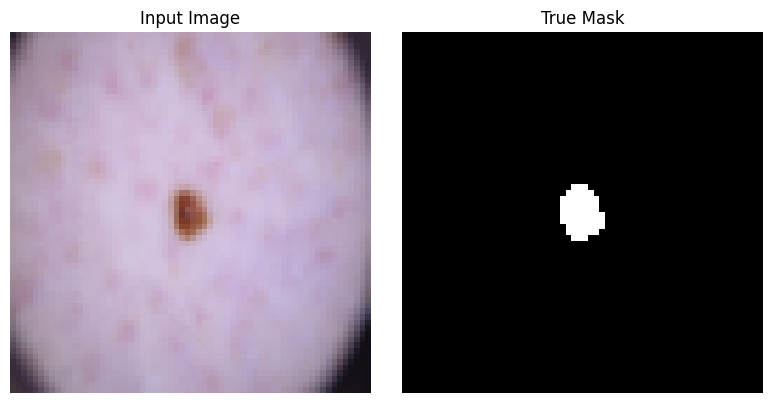

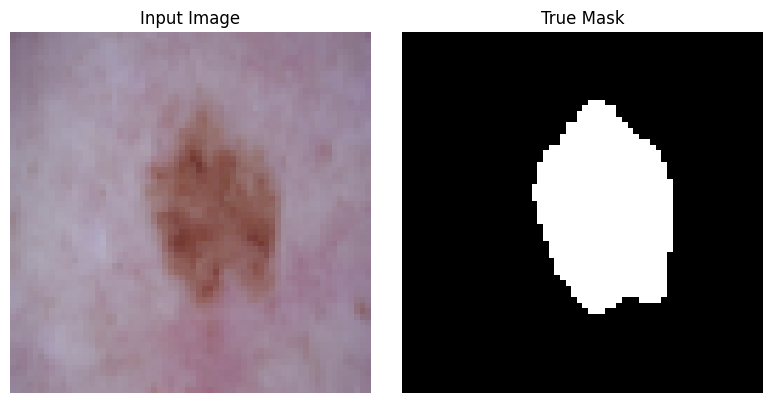

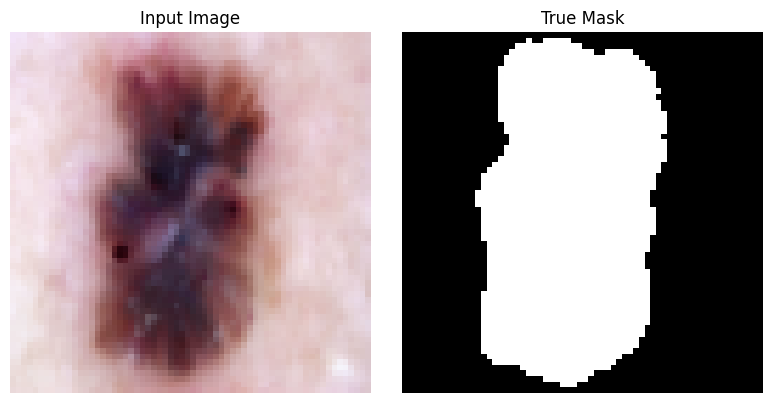

In [10]:
def display_sample(tensors, titles=None):
    if titles is None:
        titles = ["Input Image", "True Mask", "Predicted Mask"]
    n = len(tensors)
    plt.figure(figsize=(4 * n, 4))
    for i, t in enumerate(tensors):
        plt.subplot(1, n, i + 1)
        plt.title(titles[i])
        arr = t.detach().cpu()
        if arr.shape[0] in (1, 3):          # C x H x W → H x W x C
            arr = arr.permute(1, 2, 0).numpy()
        else:
            arr = arr.numpy()
        if arr.shape[-1] == 1:
            arr = arr.squeeze(-1)
        plt.imshow(arr, cmap="gray" if arr.ndim == 2 else None)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


images, masks = next(iter(train_loader))
for i in range(min(3, len(images))):
    display_sample([images[i], masks[i]], titles=["Input Image", "True Mask"])


## Modelo U-Net

In [11]:
def double_conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
    )


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(0.3)

        self.enc1 = double_conv_block(3,   64)
        self.enc2 = double_conv_block(64,  128)
        self.enc3 = double_conv_block(128, 256)
        self.enc4 = double_conv_block(256, 512)
        self.bridge = double_conv_block(512, 1024)

        self.up4  = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = double_conv_block(1024, 512)
        self.up3  = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = double_conv_block(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = double_conv_block(256, 128)
        self.up1  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = double_conv_block(128, 64)

        self.out_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.drop(self.pool(s1)))
        s3 = self.enc3(self.drop(self.pool(s2)))
        s4 = self.enc4(self.drop(self.pool(s3)))
        b  = self.bridge(self.drop(self.pool(s4)))

        x = self.dec4(torch.cat([self.up4(b),  s4], dim=1))
        x = self.dec3(torch.cat([self.up3(x),  s3], dim=1))
        x = self.dec2(torch.cat([self.up2(x),  s2], dim=1))
        x = self.dec1(torch.cat([self.up1(x),  s1], dim=1))
        return self.out_conv(x)


if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

model = UNet().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Device: {DEVICE}")
print(f"Parâmetros: {n_params:,}")


Device: mps
Parâmetros: 31,031,745


## Treinamento

In [12]:
EPOCHS    = 20
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {"train_loss": [], "val_loss": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(images), masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(images)
    train_loss /= len(train_dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            val_loss += criterion(model(images), masks).item() * len(images)
    val_loss /= len(val_dataset)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")


Epoch 01/20 | train_loss=0.3991 | val_loss=0.2866
Epoch 02/20 | train_loss=0.2549 | val_loss=0.2201
Epoch 03/20 | train_loss=0.2028 | val_loss=0.1804
Epoch 04/20 | train_loss=0.1821 | val_loss=0.1758
Epoch 05/20 | train_loss=0.1727 | val_loss=0.1518
Epoch 06/20 | train_loss=0.1676 | val_loss=0.1580
Epoch 07/20 | train_loss=0.1629 | val_loss=0.1519
Epoch 08/20 | train_loss=0.1586 | val_loss=0.1481
Epoch 09/20 | train_loss=0.1594 | val_loss=0.1411
Epoch 10/20 | train_loss=0.1532 | val_loss=0.1392
Epoch 11/20 | train_loss=0.1506 | val_loss=0.1349
Epoch 12/20 | train_loss=0.1486 | val_loss=0.1474
Epoch 13/20 | train_loss=0.1466 | val_loss=0.1366
Epoch 14/20 | train_loss=0.1481 | val_loss=0.1337
Epoch 15/20 | train_loss=0.1444 | val_loss=0.1289
Epoch 16/20 | train_loss=0.1468 | val_loss=0.1336
Epoch 17/20 | train_loss=0.1425 | val_loss=0.1366
Epoch 18/20 | train_loss=0.1443 | val_loss=0.1487
Epoch 19/20 | train_loss=0.1413 | val_loss=0.1308
Epoch 20/20 | train_loss=0.1422 | val_loss=0.1335


In [13]:
MODEL_PATH = BASE_DIR / "outputs" / "models" / "unet_segmentation.pt"
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
print(f"Modelo salvo em: {MODEL_PATH}")


Modelo salvo em: /Users/eduardoyaginuma/Documents/Repositorios/insper/skin-cancer-images-segmentation/outputs/models/unet_segmentation.pt


## Curvas de loss

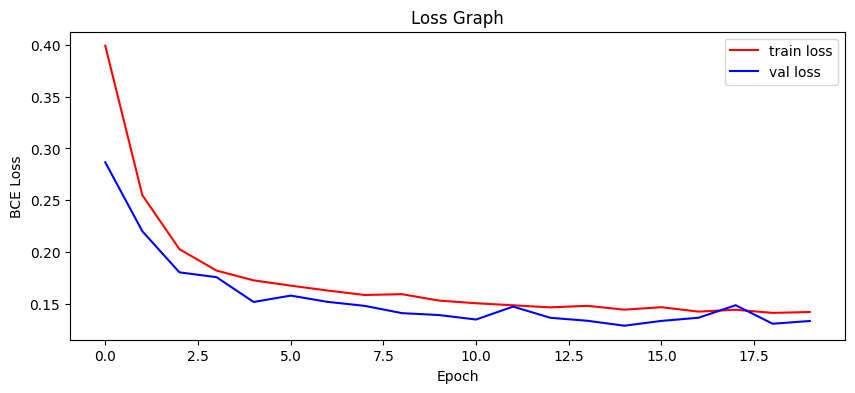

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], "r", label="train loss")
plt.plot(history["val_loss"],   "b", label="val loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Loss Graph")
plt.legend()
plt.show()


## Métricas no conjunto de teste

In [15]:
def evaluate(loader, threshold=0.5):
    model.eval()
    total_pixels = correct_pixels = 0
    intersection_sum = union_sum = dice_num = dice_den = 0.0

    with torch.no_grad():
        for images, masks in loader:
            preds = (torch.sigmoid(model(images.to(DEVICE))) > threshold).float().cpu()
            # pixel accuracy
            correct_pixels += (preds == masks).sum().item()
            total_pixels   += masks.numel()
            # IoU e Dice por imagem
            inter = (preds * masks).sum(dim=(1, 2, 3))
            union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - inter
            intersection_sum += inter.sum().item()
            union_sum        += union.sum().item()
            dice_num += (2 * inter).sum().item()
            dice_den += (preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))).sum().item()

    return {
        "pixel_acc": correct_pixels / total_pixels,
        "iou":       (intersection_sum + 1e-6) / (union_sum + 1e-6),
        "dice":      (dice_num + 1e-6)          / (dice_den + 1e-6),
    }


metrics = evaluate(test_loader)
print(f"Pixel Accuracy : {metrics['pixel_acc']:.4f} ({metrics['pixel_acc']*100:.2f}%)")
print(f"IoU (Jaccard)  : {metrics['iou']:.4f}")
print(f"Dice           : {metrics['dice']:.4f}")


Pixel Accuracy : 0.9430 (94.30%)
IoU (Jaccard)  : 0.8104
Dice           : 0.8952


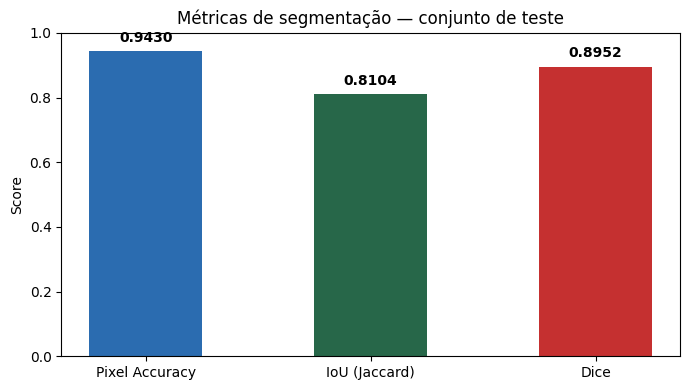

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
names  = ["Pixel Accuracy", "IoU (Jaccard)", "Dice"]
values = [metrics["pixel_acc"], metrics["iou"], metrics["dice"]]
bars   = ax.bar(names, values, color=["#2b6cb0", "#276749", "#c53030"], width=0.5)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Métricas de segmentação — conjunto de teste")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.4f}",
            ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()


## Precision, Recall e F1 — nível de pixel

A classe positiva é o pixel de lesão (máscara = 1).  
- **Precision**: dos pixels previstos como lesão, quantos realmente são?  
- **Recall**: dos pixels que são lesão, quantos o modelo encontrou?  
- **F1**: média harmônica (= Dice).  
- **Specificity**: dos pixels de fundo, quantos foram corretamente ignorados?

In [17]:
def pixel_classification_metrics(loader, threshold=0.5):
    model.eval()
    tp = fp = fn = tn = 0
    with torch.no_grad():
        for images, masks in loader:
            preds = (torch.sigmoid(model(images.to(DEVICE))) > threshold).float().cpu()
            masks = masks.float()
            tp += (preds * masks).sum().item()
            fp += (preds * (1 - masks)).sum().item()
            fn += ((1 - preds) * masks).sum().item()
            tn += ((1 - preds) * (1 - masks)).sum().item()

    precision    = tp / (tp + fp + 1e-8)
    recall       = tp / (tp + fn + 1e-8)
    specificity  = tn / (tn + fp + 1e-8)
    f1           = 2 * precision * recall / (precision + recall + 1e-8)
    accuracy     = (tp + tn) / (tp + fp + fn + tn + 1e-8)
    return dict(precision=precision, recall=recall,
                specificity=specificity, f1=f1, accuracy=accuracy,
                tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn))


m = pixel_classification_metrics(test_loader)

print("─" * 40)
print(f"  Precision   : {m['precision']:.4f}")
print(f"  Recall      : {m['recall']:.4f}")
print(f"  Specificity : {m['specificity']:.4f}")
print(f"  F1 (= Dice) : {m['f1']:.4f}")
print(f"  Accuracy    : {m['accuracy']:.4f}")
print("─" * 40)
print(f"  TP={m['tp']:,}  FP={m['fp']:,}")
print(f"  FN={m['fn']:,}  TN={m['tn']:,}")


────────────────────────────────────────
  Precision   : 0.8956
  Recall      : 0.8949
  Specificity : 0.9610
  F1 (= Dice) : 0.8952
  Accuracy    : 0.9430
────────────────────────────────────────
  TP=1,999,052  FP=232,938
  FN=234,875  TN=5,737,423


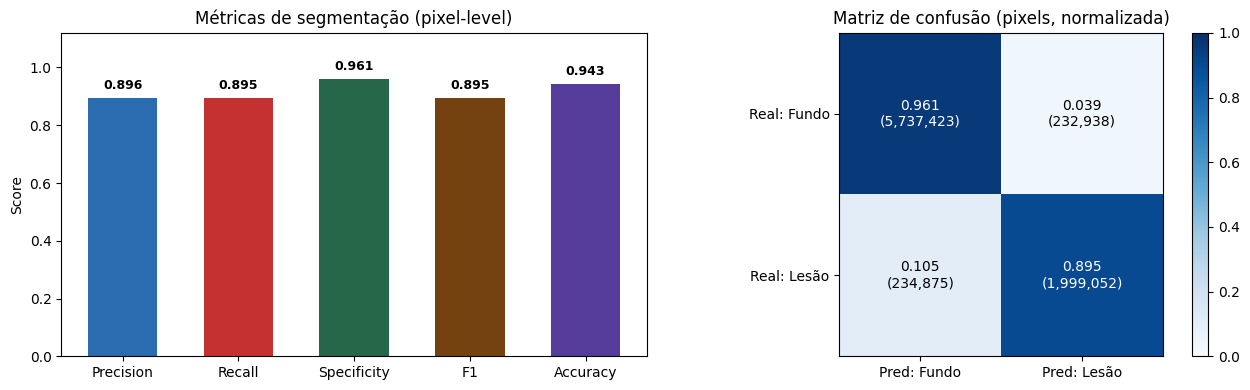

In [18]:
# Matriz de confusão de pixels (normalizada por linha)
import numpy as np

conf = np.array([[m["tn"], m["fp"]],
                 [m["fn"], m["tp"]]], dtype=float)
conf_norm = conf / conf.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Barras das métricas ---
metric_names  = ["Precision", "Recall", "Specificity", "F1", "Accuracy"]
metric_values = [m["precision"], m["recall"], m["specificity"], m["f1"], m["accuracy"]]
colors = ["#2b6cb0", "#c53030", "#276749", "#744210", "#553c9a"]
bars = axes[0].bar(metric_names, metric_values, color=colors, width=0.6)
axes[0].set_ylim(0, 1.12)
axes[0].set_title("Métricas de segmentação (pixel-level)")
axes[0].set_ylabel("Score")
for bar, v in zip(bars, metric_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                 f"{v:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=9)

# --- Matriz de confusão ---
im = axes[1].imshow(conf_norm, cmap="Blues", vmin=0, vmax=1)
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Pred: Fundo", "Pred: Lesão"])
axes[1].set_yticklabels(["Real: Fundo", "Real: Lesão"])
axes[1].set_title("Matriz de confusão (pixels, normalizada)")
for r in range(2):
    for c in range(2):
        axes[1].text(c, r, f"{conf_norm[r, c]:.3f}\n({int(conf[r,c]):,})",
                     ha="center", va="center",
                     color="white" if conf_norm[r, c] > 0.5 else "black", fontsize=10)
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()


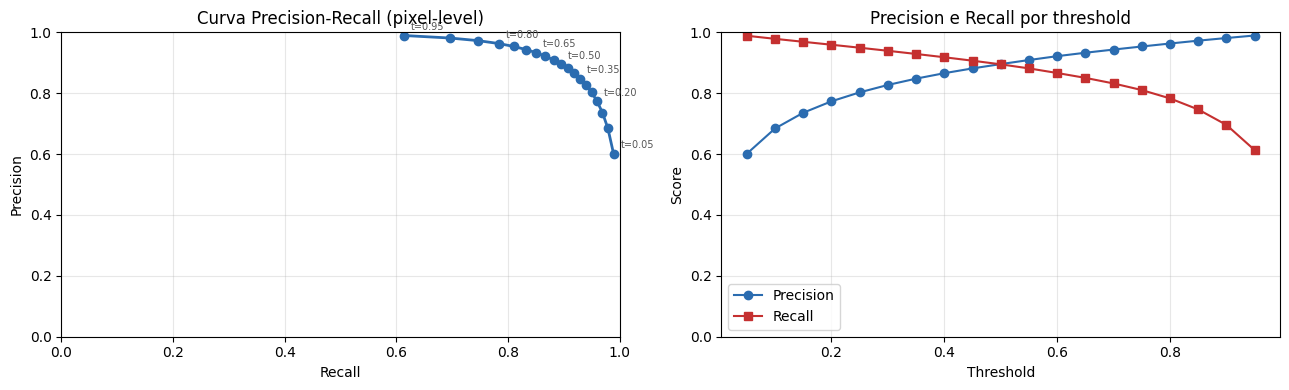

In [19]:
# Curva Precision-Recall variando o threshold
thresholds = torch.linspace(0.05, 0.95, 19).tolist()
pr_points  = []

model.eval()
with torch.no_grad():
    all_probs, all_masks = [], []
    for images, masks in test_loader:
        probs = torch.sigmoid(model(images.to(DEVICE))).cpu()
        all_probs.append(probs)
        all_masks.append(masks)
    all_probs = torch.cat(all_probs)
    all_masks = torch.cat(all_masks).float()

for thr in thresholds:
    preds = (all_probs > thr).float()
    tp = (preds * all_masks).sum().item()
    fp = (preds * (1 - all_masks)).sum().item()
    fn = ((1 - preds) * all_masks).sum().item()
    pr = tp / (tp + fp + 1e-8)
    re = tp / (tp + fn + 1e-8)
    pr_points.append((re, pr, thr))

recalls, precisions, thrs = zip(*pr_points)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Curva PR
axes[0].plot(recalls, precisions, marker="o", color="#2b6cb0", linewidth=2)
for re, pr, thr in pr_points[::3]:
    axes[0].annotate(f"t={thr:.2f}", (re, pr), textcoords="offset points",
                     xytext=(5, 4), fontsize=7, color="#555")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].set_title("Curva Precision-Recall (pixel-level)")
axes[0].grid(alpha=0.3)

# Precision e Recall vs threshold
axes[1].plot(thrs, precisions, marker="o", label="Precision", color="#2b6cb0")
axes[1].plot(thrs, recalls,    marker="s", label="Recall",    color="#c53030")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision e Recall por threshold")
axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()


## Acertos por imagem (IoU por sample)

In [20]:
IOU_THRESHOLD = 0.5  # considera "acerto" quando IoU >= 0.5

per_image_iou = []
model.eval()
with torch.no_grad():
    for images, masks in test_loader:
        preds = (torch.sigmoid(model(images.to(DEVICE))) > 0.5).float().cpu()
        inter = (preds * masks).sum(dim=(1, 2, 3))
        union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - inter
        iou_batch = ((inter + 1e-6) / (union + 1e-6)).tolist()
        per_image_iou.extend(iou_batch)

per_image_iou = torch.tensor(per_image_iou)
acertos = (per_image_iou >= IOU_THRESHOLD).sum().item()
total   = len(per_image_iou)

print(f"Threshold de acerto : IoU >= {IOU_THRESHOLD}")
print(f"Acertos             : {acertos} / {total}  ({100*acertos/total:.1f}%)")
print(f"Erros               : {total - acertos} / {total}  ({100*(total-acertos)/total:.1f}%)")
print(f"\nIoU médio  : {per_image_iou.mean():.4f}")
print(f"IoU mediana: {per_image_iou.median():.4f}")


Threshold de acerto : IoU >= 0.5
Acertos             : 1865 / 2003  (93.1%)
Erros               : 138 / 2003  (6.9%)

IoU médio  : 0.8131
IoU mediana: 0.8783


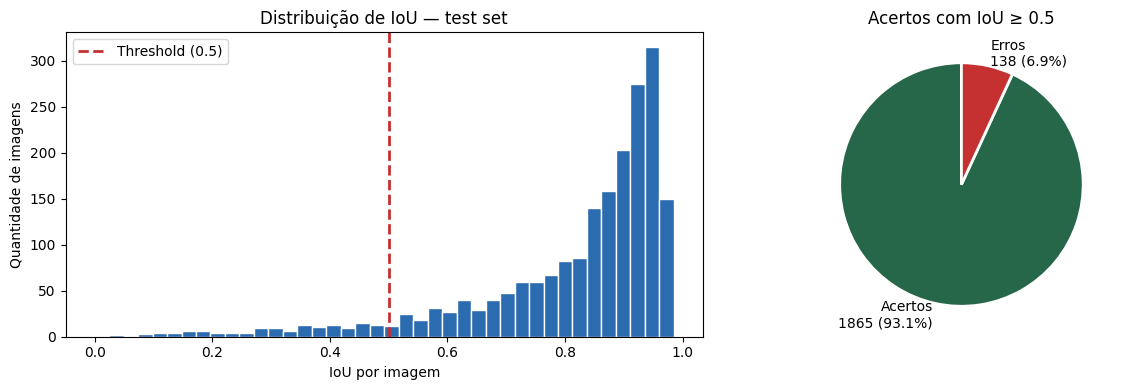

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de IoU por imagem
axes[0].hist(per_image_iou.numpy(), bins=40, color="#2b6cb0", edgecolor="white")
axes[0].axvline(IOU_THRESHOLD, color="#c53030", linestyle="--", linewidth=2,
                label=f"Threshold ({IOU_THRESHOLD})")
axes[0].set_xlabel("IoU por imagem")
axes[0].set_ylabel("Quantidade de imagens")
axes[0].set_title("Distribuição de IoU — test set")
axes[0].legend()

# Pizza acertos vs erros
axes[1].pie(
    [acertos, total - acertos],
    labels=[f"Acertos\n{acertos} ({100*acertos/total:.1f}%)",
            f"Erros\n{total-acertos} ({100*(total-acertos)/total:.1f}%)"],
    colors=["#276749", "#c53030"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title(f"Acertos com IoU ≥ {IOU_THRESHOLD}")

plt.tight_layout()
plt.show()


## Visualização das predições

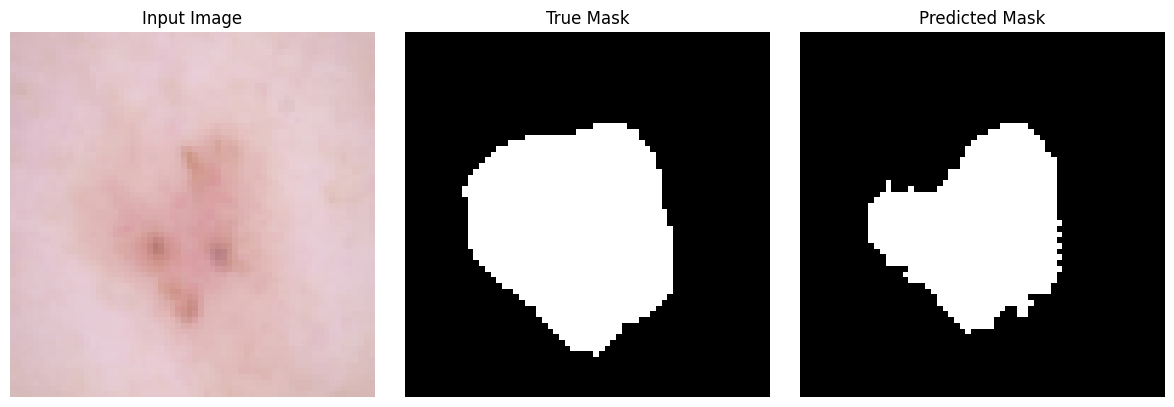

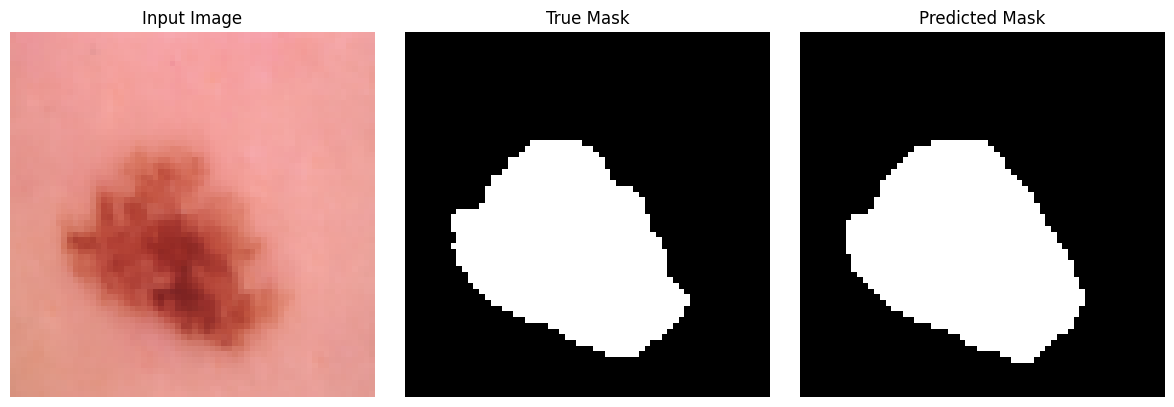

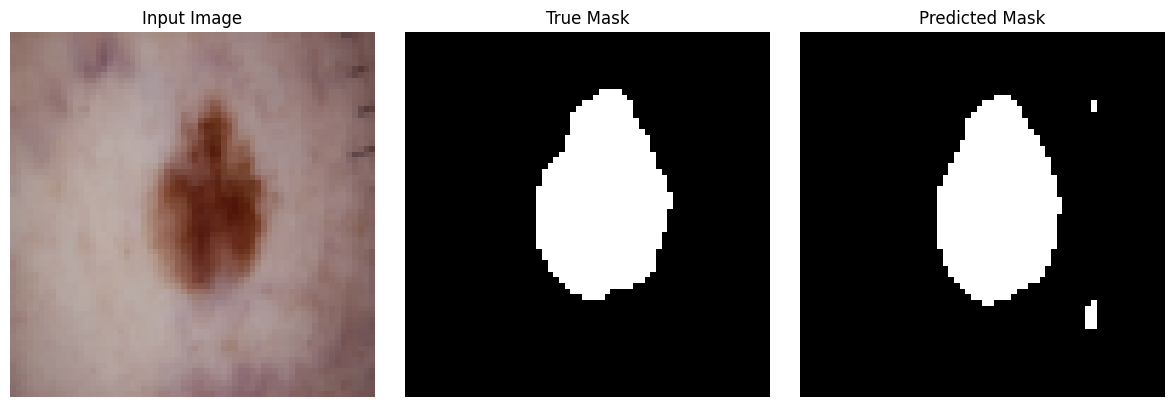

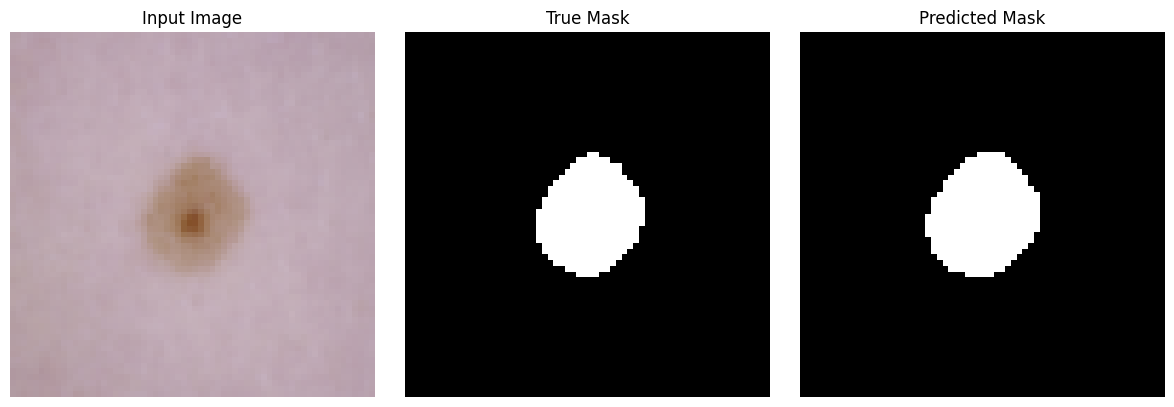

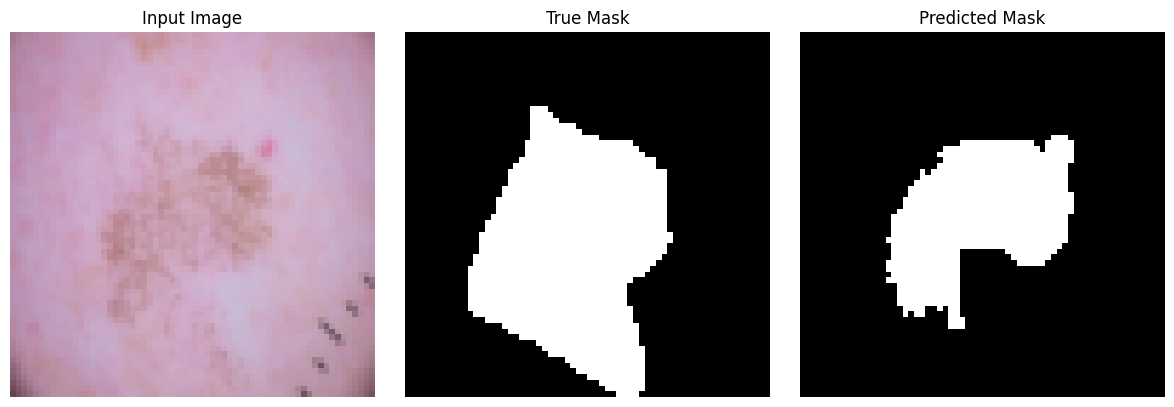

In [22]:
def create_prediction_mask(logits):
    return (torch.sigmoid(logits) > 0.5).float()


def segment_image(loader, num=3):
    model.eval()
    with torch.no_grad():
        for images, masks in loader:
            pred_masks = create_prediction_mask(model(images.to(DEVICE))).cpu()
            for i in range(min(num, len(images))):
                display_sample(
                    [images[i], masks[i], pred_masks[i]],
                    titles=["Input Image", "True Mask", "Predicted Mask"],
                )
            break


segment_image(val_loader, num=5)
